In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Load dataset
wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [2]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

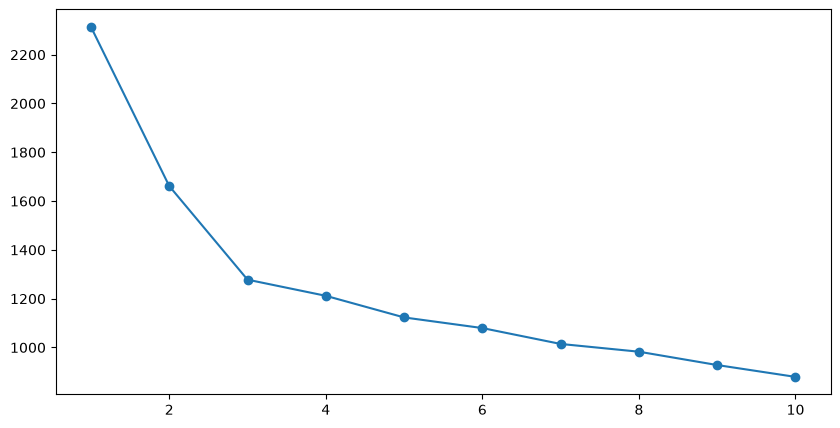

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')

In [3]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

best_k = range(2, 11)[
    silhouette_scores.index(max(silhouette_scores))
]

print("Best K:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best K: 3
Best Silhouette Score: 0.2848589191898987


In [4]:
kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [5]:
X_clustered = X.copy()

X_clustered["Cluster"] = clusters

X_clustered.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,2


In [6]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)

davies_bouldin = davies_bouldin_score(
    X_scaled,
    clusters
)

calinski_harabasz = calinski_harabasz_score(
    X_scaled,
    clusters
)

print("K-Means Evaluation")
print("-------------------")
print("Best K:", best_k)
print("Silhouette Score:", silhouette)
print("Davies-Bouldin Score:", davies_bouldin)
print("Calinski-Harabasz Score:", calinski_harabasz)

K-Means Evaluation
-------------------
Best K: 3
Silhouette Score: 0.2848589191898987
Davies-Bouldin Score: 1.3891879777181646
Calinski-Harabasz Score: 70.9400080031512


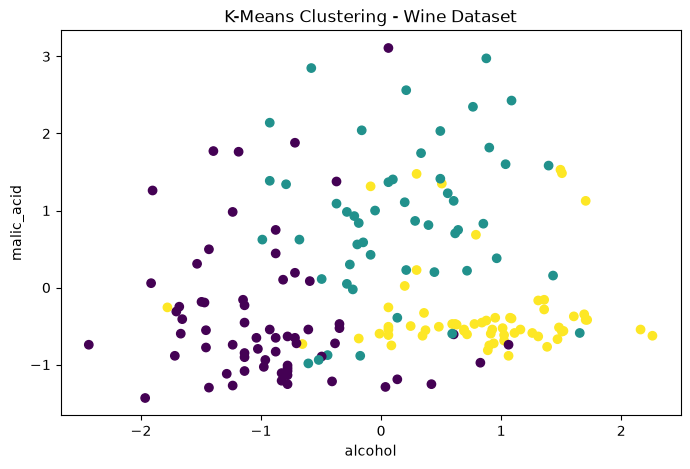

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters
)

plt.xlabel(wine.feature_names[0])
plt.ylabel(wine.feature_names[1])
plt.title("K-Means Clustering - Wine Dataset")

plt.show()

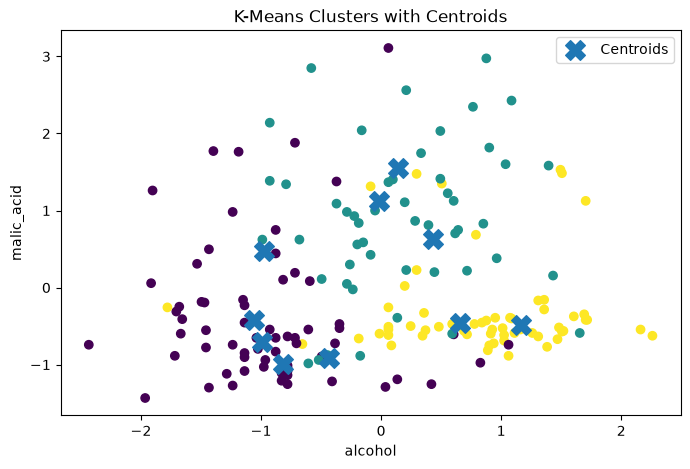

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap="viridis"
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel(wine.feature_names[0])
plt.ylabel(wine.feature_names[1])
plt.title("K-Means Clusters with Centroids")
plt.legend()

plt.show()